# Amazon E-Commerce Sales Analytics

## 08 — Geographic Analysis

### Objective

The objective of this notebook is to analyze e-commerce performance across geographic locations.

The analysis focuses on:

- Country-level performance
- State-level performance
- City-level performance
- Sales distribution by geography
- Order and customer distribution
- Units sold by location
- Average order value by location
- Geographic discount behavior
- Geographic concentration
- Top-performing locations
- Geographic performance by category
- Geographic performance by seller
- Business insights and recommendations

### Important Dataset Note

The cleaned dataset contains `City`, `State`, and `Country` fields.

These fields are analyzed as categorical geographic dimensions. The dataset does not provide latitude/longitude coordinates, so this notebook does not perform coordinate-based mapping or distance calculations.

Also, the dataset contains geographic records such as city/state/country combinations, but it does not provide shipping distance, delivery time by location, population, market size, or regional operating cost. Therefore, geographic performance is based on the observed transaction data only.


### Key Business Questions

1. Which countries generate the highest sales?
2. Which countries have the most orders and customers?
3. Which states generate the highest sales?
4. Which cities generate the highest sales?
5. Which locations sell the most units?
6. Which locations have the highest average order value?
7. Where is customer reach strongest?
8. How concentrated are sales across countries, states, and cities?
9. Which locations show the highest discount rates?
10. Which categories perform best in each country?
11. Which sellers perform best in major geographic markets?
12. Which locations should receive greater business attention?


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the cleaned dataset

file_path = "C:/Users/Hp/OneDrive/Desktop/Projects/Amazon E-Commerce Sales Performance & Customer Analytics/Data/Amazon_Cleaned.csv"

df = pd.read_csv(file_path)

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (100000, 25)


In [3]:
# Confirm geographic-analysis fields

required_columns = [
    "OrderID",
    "OrderDate",
    "CustomerID",
    "ProductID",
    "ProductName",
    "Category",
    "Brand",
    "Quantity",
    "UnitPrice",
    "Discount",
    "Tax",
    "ShippingCost",
    "TotalAmount",
    "PaymentMethod",
    "OrderStatus",
    "City",
    "State",
    "Country",
    "SellerID"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required geographic-analysis columns are available.")


All required geographic-analysis columns are available.


## 1. Geographic Data Quality Check

Before aggregation, the geographic fields are checked for missing values and unique-value counts.

This prevents incomplete location data from being silently treated as a valid geographic category.


In [4]:
geo_quality = pd.DataFrame({
    "Field": ["Country", "State", "City"],
    "Missing_Values": [
        df["Country"].isna().sum(),
        df["State"].isna().sum(),
        df["City"].isna().sum()
    ],
    "Unique_Values": [
        df["Country"].nunique(dropna=True),
        df["State"].nunique(dropna=True),
        df["City"].nunique(dropna=True)
    ],
    "Missing_Percent": [
        df["Country"].isna().mean() * 100,
        df["State"].isna().mean() * 100,
        df["City"].isna().mean() * 100
    ]
})

geo_quality


,Field,Missing_Values,Unique_Values,Missing_Percent
0,Country,0,5,0.0
1,State,0,13,0.0
2,City,0,20,0.0


In [5]:
# Inspect the geographic dimensions

print("Countries:")
display(df["Country"].value_counts(dropna=False).head(20))

print("\nStates:")
display(df["State"].value_counts(dropna=False).head(20))

print("\nCities:")
display(df["City"].value_counts(dropna=False).head(20))


Countries:


Country
United States     70058
India             15051
Canada             5818
United Kingdom     4943
Australia          4130
Name: count, dtype: int64


States:


State
TX    24896
CA    19921
NC     5110
FL     5107
WA     5039
DC     5021
OH     5021
IL     5020
PA     5014
CO     4991
IN     4970
NY     4949
AZ     4941
Name: count, dtype: int64


Cities:


City
Charlotte        5110
Jacksonville     5107
San Jose         5107
Dallas           5105
Los Angeles      5058
Austin           5043
Seattle          5039
Washington       5021
Columbus         5021
Chicago          5020
Philadelphia     5014
Denver           4991
Indianapolis     4970
New York         4949
Phoenix          4941
Fort Worth       4934
San Francisco    4930
San Antonio      4913
Houston          4901
San Diego        4826
Name: count, dtype: int64

## 2. Geographic-Level Derived Metrics

The geographic analysis uses consistent sales measures from the previous notebooks:

- **Gross Product Value** = `Quantity × UnitPrice`
- **Discount Amount** = `Gross Product Value × Discount`
- **Net Product Sales** = `Gross Product Value − Discount Amount`
- **Effective Unit Price** = `UnitPrice × (1 − Discount)`

`TotalAmount` is retained as total recorded order value and includes the dataset's tax and shipping components.


In [6]:
# Create common transaction metrics

df["GrossProductValue"] = df["Quantity"] * df["UnitPrice"]

df["DiscountAmount"] = (
    df["GrossProductValue"] * df["Discount"]
)

df["NetProductSales"] = (
    df["GrossProductValue"] - df["DiscountAmount"]
)

df["EffectiveUnitPrice"] = (
    df["UnitPrice"] * (1 - df["Discount"])
)

df["DiscountPercent"] = df["Discount"] * 100

df[
    [
        "Country",
        "State",
        "City",
        "Quantity",
        "UnitPrice",
        "Discount",
        "GrossProductValue",
        "NetProductSales",
        "TotalAmount"
    ]
].head()


,Country,State,City,Quantity,UnitPrice,Discount,GrossProductValue,NetProductSales,TotalAmount
0,India,DC,Washington,3,106.59,0.00,319.77,319.7700,319.86
1,United States,TX,Fort Worth,1,251.37,0.05,251.37,238.8015,259.64
2,United States,TX,Austin,3,35.03,0.10,105.09,94.5810,108.06
3,India,NC,Charlotte,5,33.58,0.15,167.90,142.7150,159.66
4,Canada,TX,San Antonio,2,515.64,0.25,1031.28,773.4600,821.36


## 3. Overall Geographic Overview

This section summarizes the number of geographic markets represented in the dataset and the overall transaction scale.


In [7]:
geographic_overview = pd.DataFrame({
    "Metric": [
        "Countries",
        "States",
        "Cities",
        "Orders",
        "Customers",
        "Units Sold",
        "Net Product Sales",
        "Total Order Value"
    ],
    "Value": [
        df["Country"].nunique(),
        df["State"].nunique(),
        df["City"].nunique(),
        df["OrderID"].nunique(),
        df["CustomerID"].nunique(),
        df["Quantity"].sum(),
        df["NetProductSales"].sum(),
        df["TotalAmount"].sum()
    ]
})

geographic_overview


,Metric,Value
0,Countries,5.000000e+00
1,States,1.300000e+01
2,Cities,2.000000e+01
3,Orders,1.000000e+05
4,Customers,4.323300e+04
5,Units Sold,3.001400e+05
6,Net Product Sales,8.423809e+07
7,Total Order Value,9.182565e+07


## 4. Country-Level Performance

Country-level analysis provides the highest-level geographic view of marketplace activity.


In [8]:
country_summary = (
    df.groupby("Country")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Cities=("City", "nunique"),
          States=("State", "nunique"),
          Sellers=("SellerID", "nunique"),
          Products=("ProductID", "nunique"),
          Categories=("Category", "nunique"),
          Units=("Quantity", "sum"),
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Average_Unit_Price=("UnitPrice", "mean"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

country_summary["Weighted_Discount_%"] = (
    country_summary["DiscountAmount"]
    / country_summary["GrossProductValue"]
    * 100
)

country_summary["Sales_Share_%"] = (
    country_summary["NetProductSales"]
    / country_summary["NetProductSales"].sum()
    * 100
)

country_summary["Customer_Share_%"] = (
    country_summary["Customers"]
    / country_summary["Customers"].sum()
    * 100
)

country_summary = country_summary.sort_values(
    "NetProductSales",
    ascending=False
)

country_summary


,Country,Orders,Customers,Cities,States,Sellers,Products,Categories,Units,GrossProductValue,DiscountAmount,NetProductSales,TotalOrderValue,Average_Order_Value,Average_Unit_Price,Average_Discount,Weighted_Discount_%,Sales_Share_%,Customer_Share_%
4,United States,70058,37731,20,13,1999,50,6,210409,63746228.16,4.752212e+06,5.899402e+07,64310048.50,917.954388,302.648085,0.074073,7.454891,70.032468,58.133551
2,India,15051,12976,20,13,1999,50,6,45082,13737728.01,1.009473e+06,1.272826e+07,13875839.12,921.921409,304.354626,0.074101,7.348180,15.109856,19.992604
1,Canada,5818,5486,20,13,1897,50,6,17381,5283259.18,3.976261e+05,4.885633e+06,5323757.00,915.049330,303.039876,0.074467,7.526152,5.799791,8.452484
3,United Kingdom,4943,4742,20,13,1823,50,6,14831,4494987.10,3.391589e+05,4.155828e+06,4526896.86,915.819717,301.716316,0.075733,7.545270,4.933431,7.306175
0,Australia,4130,3969,20,13,1749,50,6,12437,3759010.54,2.846493e+05,3.474361e+06,3789106.44,917.459186,303.231015,0.075133,7.572452,4.124454,6.115186


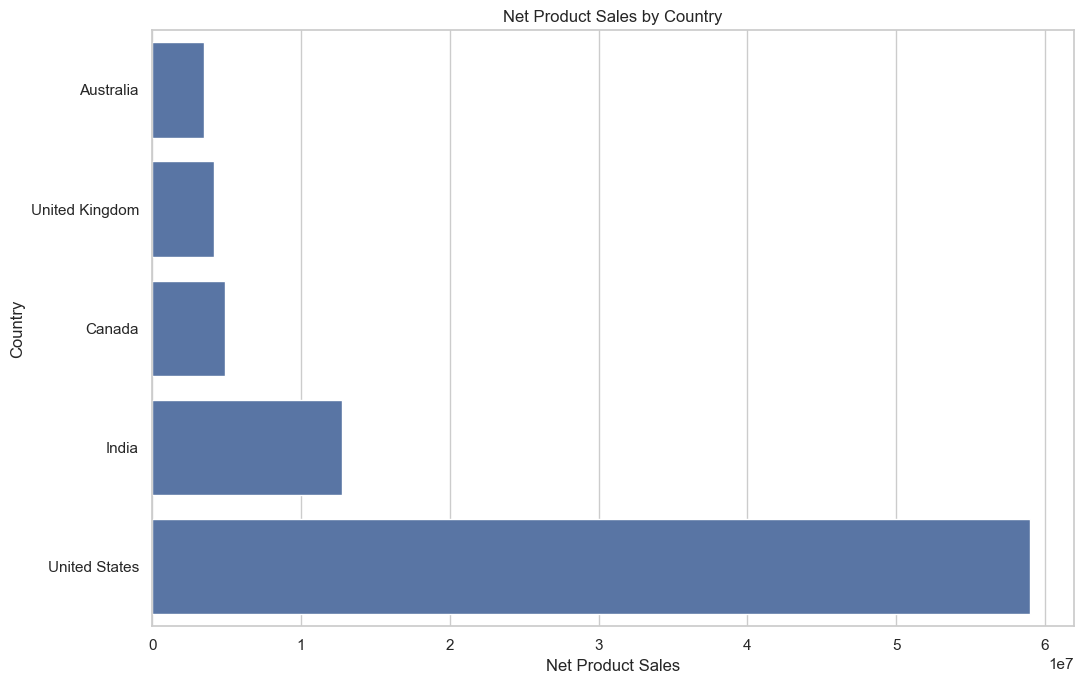

In [9]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=country_summary.sort_values("NetProductSales"),
    x="NetProductSales",
    y="Country"
)

plt.title("Net Product Sales by Country")
plt.xlabel("Net Product Sales")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


### Country Sales Share

Sales share shows how much of total net product sales comes from each country.

This is more informative than raw sales alone when comparing market concentration.


In [10]:
country_sales_share = country_summary[
    [
        "Country",
        "NetProductSales",
        "Sales_Share_%",
        "Orders",
        "Customers",
        "Units"
    ]
].copy()

country_sales_share


,Country,NetProductSales,Sales_Share_%,Orders,Customers,Units
4,United States,5.899402e+07,70.032468,70058,37731,210409
2,India,1.272826e+07,15.109856,15051,12976,45082
1,Canada,4.885633e+06,5.799791,5818,5486,17381
3,United Kingdom,4.155828e+06,4.933431,4943,4742,14831
0,Australia,3.474361e+06,4.124454,4130,3969,12437


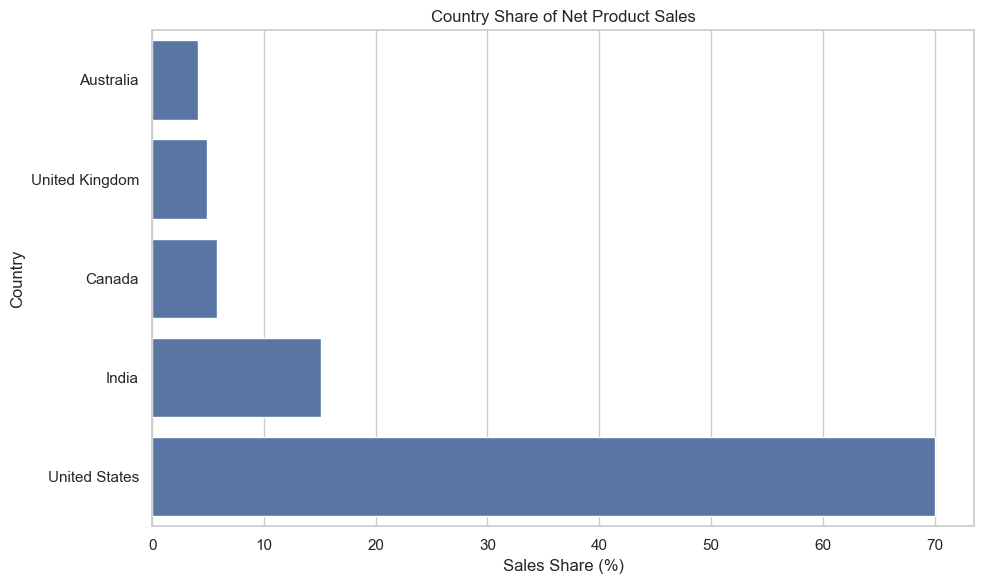

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_sales_share.sort_values("Sales_Share_%"),
    x="Sales_Share_%",
    y="Country"
)

plt.title("Country Share of Net Product Sales")
plt.xlabel("Sales Share (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


## 5. Country-Level Customer Reach

Customer counts indicate the breadth of the customer base in each country.


In [12]:
country_customer_rank = (
    country_summary
    .sort_values("Customers", ascending=False)
)

country_customer_rank[
    [
        "Country",
        "Customers",
        "Orders",
        "Units",
        "NetProductSales",
        "Average_Order_Value"
    ]
]


,Country,Customers,Orders,Units,NetProductSales,Average_Order_Value
4,United States,37731,70058,210409,5.899402e+07,917.954388
2,India,12976,15051,45082,1.272826e+07,921.921409
1,Canada,5486,5818,17381,4.885633e+06,915.049330
3,United Kingdom,4742,4943,14831,4.155828e+06,915.819717
0,Australia,3969,4130,12437,3.474361e+06,917.459186


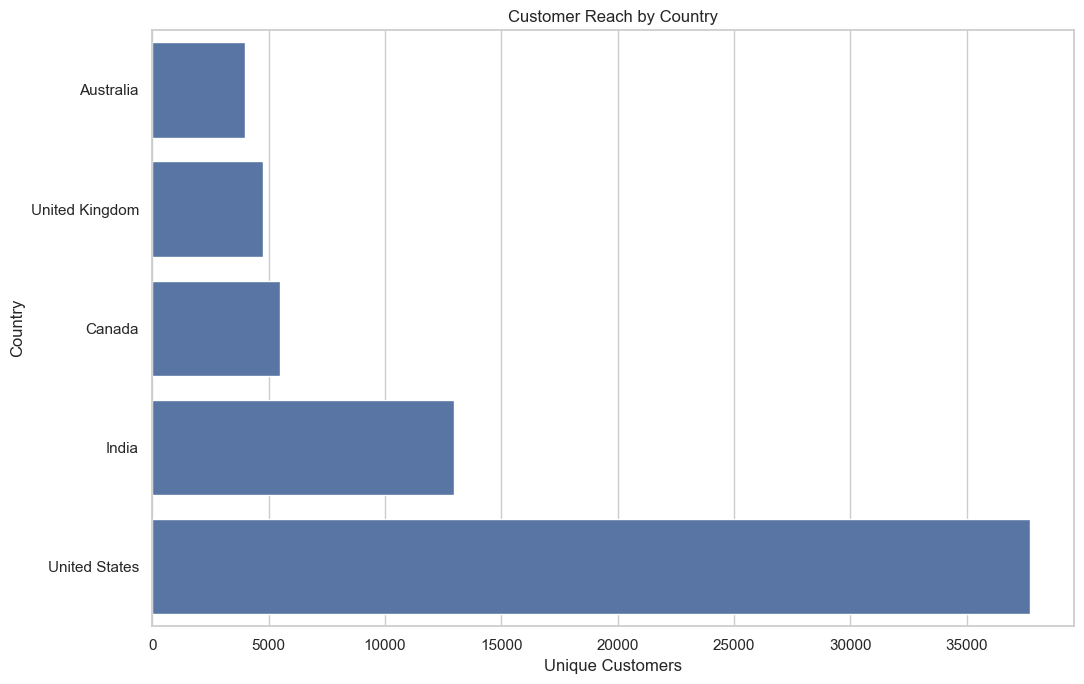

In [13]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=country_customer_rank.sort_values("Customers"),
    x="Customers",
    y="Country"
)

plt.title("Customer Reach by Country")
plt.xlabel("Unique Customers")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


## 6. Country-Level Average Order Value

Average order value is used to identify markets where individual recorded orders tend to have higher monetary value.

Because `TotalAmount` includes tax and shipping, this metric is an order-value measure rather than pure product revenue.


In [14]:
country_aov = (
    country_summary
    .sort_values("Average_Order_Value", ascending=False)
)

country_aov[
    [
        "Country",
        "Average_Order_Value",
        "Orders",
        "Customers",
        "NetProductSales"
    ]
]


,Country,Average_Order_Value,Orders,Customers,NetProductSales
2,India,921.921409,15051,12976,1.272826e+07
4,United States,917.954388,70058,37731,5.899402e+07
0,Australia,917.459186,4130,3969,3.474361e+06
3,United Kingdom,915.819717,4943,4742,4.155828e+06
1,Canada,915.049330,5818,5486,4.885633e+06


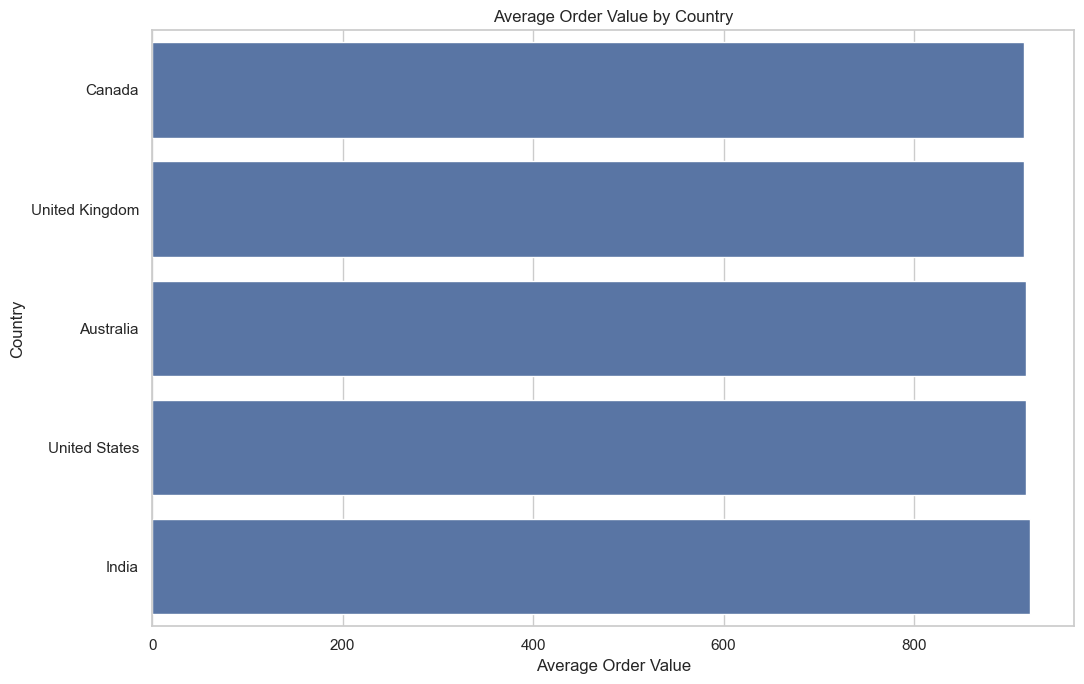

In [15]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=country_aov.sort_values("Average_Order_Value"),
    x="Average_Order_Value",
    y="Country"
)

plt.title("Average Order Value by Country")
plt.xlabel("Average Order Value")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


## 7. Country-Level Discount Behavior

This section compares discount intensity across countries.

A high weighted discount rate means a larger share of gross product value was discounted in that country's transactions.

It does not measure profitability because product cost and margin are unavailable.


In [16]:
country_discount = (
    country_summary
    .sort_values("Weighted_Discount_%", ascending=False)
)

country_discount[
    [
        "Country",
        "Weighted_Discount_%",
        "Average_Discount",
        "DiscountAmount",
        "NetProductSales"
    ]
]


,Country,Weighted_Discount_%,Average_Discount,DiscountAmount,NetProductSales
0,Australia,7.572452,0.075133,2.846493e+05,3.474361e+06
3,United Kingdom,7.545270,0.075733,3.391589e+05,4.155828e+06
1,Canada,7.526152,0.074467,3.976261e+05,4.885633e+06
4,United States,7.454891,0.074073,4.752212e+06,5.899402e+07
2,India,7.348180,0.074101,1.009473e+06,1.272826e+07


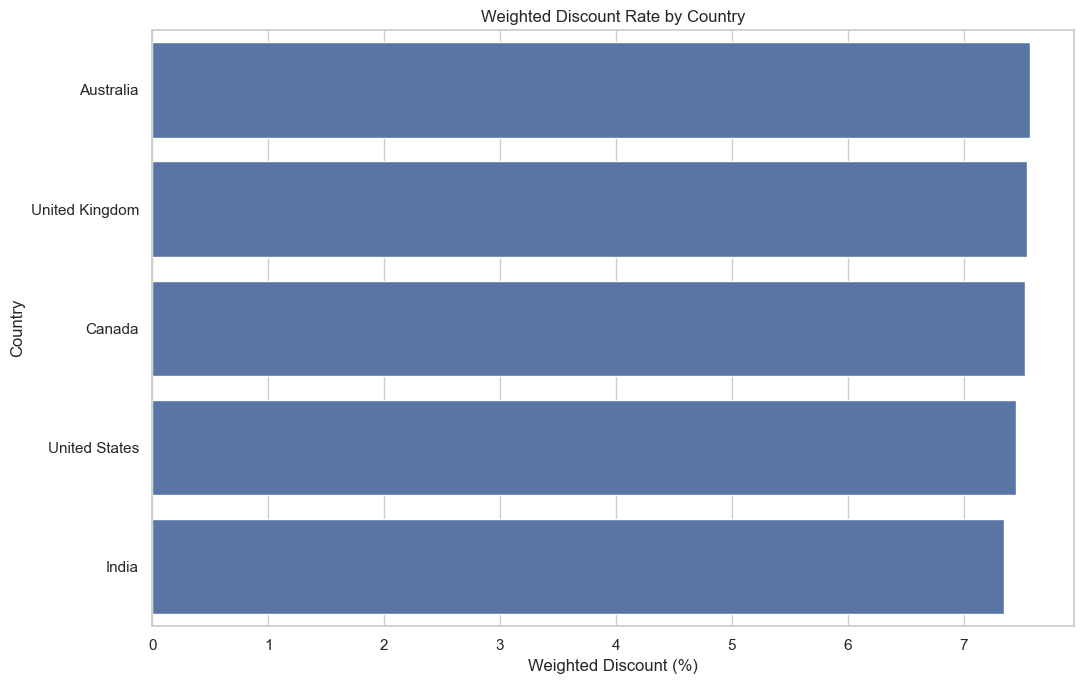

In [17]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=country_discount,
    x="Weighted_Discount_%",
    y="Country"
)

plt.title("Weighted Discount Rate by Country")
plt.xlabel("Weighted Discount (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


## 8. State-Level Performance

State-level analysis provides a more detailed geographic view within the country/state structure represented in the dataset.

The `State` field is analyzed as provided in the cleaned data and is not independently re-geocoded.


In [18]:
state_summary = (
    df.groupby(["Country", "State"])
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Cities=("City", "nunique"),
          Sellers=("SellerID", "nunique"),
          Products=("ProductID", "nunique"),
          Categories=("Category", "nunique"),
          Units=("Quantity", "sum"),
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

state_summary["Weighted_Discount_%"] = (
    state_summary["DiscountAmount"]
    / state_summary["GrossProductValue"]
    * 100
)

state_summary["Sales_Share_%"] = (
    state_summary["NetProductSales"]
    / state_summary["NetProductSales"].sum()
    * 100
)

state_summary = state_summary.sort_values(
    "NetProductSales",
    ascending=False
)

state_summary.head(20)


,Country,State,Orders,Customers,Cities,Sellers,Products,Categories,Units,GrossProductValue,DiscountAmount,NetProductSales,TotalOrderValue,Average_Order_Value,Average_Discount,Weighted_Discount_%,Sales_Share_%
63,United States,TX,17334,14662,5,1999,50,6,52001,15759021.89,1.167770e+06,1.459125e+07,15897488.53,917.127526,0.073333,7.410167,17.321441
53,United States,CA,14014,12277,4,1999,50,6,41949,12657897.56,9.455216e+05,1.171238e+07,12783662.94,912.206575,0.074336,7.469816,13.903895
37,India,TX,3797,3648,5,1708,50,6,11322,3473829.43,2.591616e+05,3.214668e+06,3503209.66,922.625668,0.074783,7.460399,3.816169
59,United States,NC,3606,3467,1,1652,50,6,10867,3280118.24,2.464979e+05,3.033620e+06,3311877.73,918.435311,0.074251,7.514910,3.601245
56,United States,FL,3594,3479,1,1667,50,6,10870,3261080.99,2.459673e+05,3.015114e+06,3281693.36,913.103328,0.074610,7.542508,3.579276
62,United States,PA,3543,3409,1,1684,50,6,10737,3260075.73,2.451369e+05,3.014939e+06,3287459.93,927.874663,0.074527,7.519363,3.579068
57,United States,IL,3507,3402,1,1647,50,6,10521,3241592.32,2.453910e+05,2.996201e+06,3268618.39,932.026915,0.074950,7.570075,3.556825
58,United States,IN,3469,3364,1,1659,50,6,10445,3221849.84,2.436980e+05,2.978152e+06,3246583.55,935.884563,0.075166,7.563914,3.535398
54,United States,CO,3462,3334,1,1643,50,6,10511,3205263.52,2.331764e+05,2.972087e+06,3240143.04,935.916534,0.072039,7.274795,3.528199
61,United States,OH,3521,3392,1,1661,50,6,10597,3187501.95,2.198293e+05,2.967673e+06,3237947.84,919.610293,0.070420,6.896602,3.522958


### Top States by Net Product Sales

The ranking below identifies the highest-sales country/state combinations.


In [19]:
top_states_sales = (
    state_summary
    .sort_values("NetProductSales", ascending=False)
    .head(20)
)

top_states_sales[
    [
        "Country",
        "State",
        "Orders",
        "Customers",
        "Units",
        "NetProductSales",
        "Sales_Share_%"
    ]
]


,Country,State,Orders,Customers,Units,NetProductSales,Sales_Share_%
63,United States,TX,17334,14662,52001,1.459125e+07,17.321441
53,United States,CA,14014,12277,41949,1.171238e+07,13.903895
37,India,TX,3797,3648,11322,3.214668e+06,3.816169
59,United States,NC,3606,3467,10867,3.033620e+06,3.601245
56,United States,FL,3594,3479,10870,3.015114e+06,3.579276
62,United States,PA,3543,3409,10737,3.014939e+06,3.579068
57,United States,IL,3507,3402,10521,2.996201e+06,3.556825
58,United States,IN,3469,3364,10445,2.978152e+06,3.535398
54,United States,CO,3462,3334,10511,2.972087e+06,3.528199
61,United States,OH,3521,3392,10597,2.967673e+06,3.522958


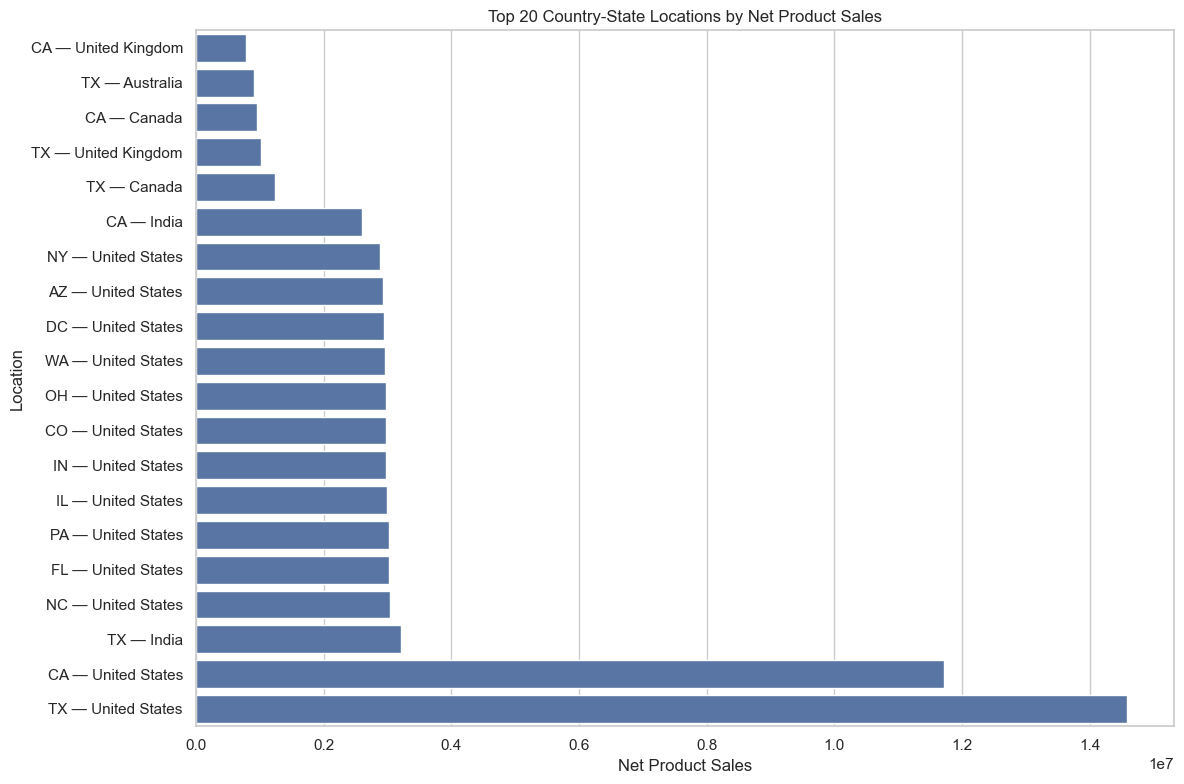

In [20]:
top_states_plot = top_states_sales.copy()

top_states_plot["Location"] = (
    top_states_plot["State"].astype(str)
    + " — "
    + top_states_plot["Country"].astype(str)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_states_plot.sort_values("NetProductSales"),
    x="NetProductSales",
    y="Location"
)

plt.title("Top 20 Country-State Locations by Net Product Sales")
plt.xlabel("Net Product Sales")
plt.ylabel("Location")

plt.tight_layout()
plt.show()


## 9. City-Level Performance

City-level analysis identifies the most important individual markets in the dataset.


In [21]:
city_summary = (
    df.groupby(["Country", "State", "City"])
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Sellers=("SellerID", "nunique"),
          Products=("ProductID", "nunique"),
          Categories=("Category", "nunique"),
          Units=("Quantity", "sum"),
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

city_summary["Weighted_Discount_%"] = (
    city_summary["DiscountAmount"]
    / city_summary["GrossProductValue"]
    * 100
)

city_summary["Sales_Share_%"] = (
    city_summary["NetProductSales"]
    / city_summary["NetProductSales"].sum()
    * 100
)

city_summary = city_summary.sort_values(
    "NetProductSales",
    ascending=False
)

city_summary.head(20)


,Country,State,City,Orders,Customers,Sellers,Products,Categories,Units,GrossProductValue,DiscountAmount,NetProductSales,TotalOrderValue,Average_Order_Value,Average_Discount,Weighted_Discount_%,Sales_Share_%
90,United States,NC,Charlotte,3606,3467,1652,50,6,10867,3280118.24,246497.9340,3.033620e+06,3311877.73,918.435311,0.074251,7.514910,3.601245
95,United States,TX,Dallas,3549,3428,1676,50,6,10760,3277783.44,248874.1155,3.028909e+06,3302355.14,930.502998,0.074570,7.592757,3.595653
81,United States,CA,Los Angeles,3571,3445,1686,50,6,10654,3264047.65,244423.9410,3.019624e+06,3293609.37,922.321302,0.075189,7.488369,3.584630
87,United States,FL,Jacksonville,3594,3479,1667,50,6,10870,3261080.99,245967.3085,3.015114e+06,3281693.36,913.103328,0.074610,7.542508,3.579276
93,United States,PA,Philadelphia,3543,3409,1684,50,6,10737,3260075.73,245136.9320,3.014939e+06,3287459.93,927.874663,0.074527,7.519363,3.579068
88,United States,IL,Chicago,3507,3402,1647,50,6,10521,3241592.32,245390.9660,2.996201e+06,3268618.39,932.026915,0.074950,7.570075,3.556825
84,United States,CA,San Jose,3619,3492,1665,50,6,10815,3220105.74,239534.6115,2.980571e+06,3256968.78,899.963741,0.075863,7.438719,3.538270
89,United States,IN,Indianapolis,3469,3364,1659,50,6,10445,3221849.84,243697.9640,2.978152e+06,3246583.55,935.884563,0.075166,7.563914,3.535398
85,United States,CO,Denver,3462,3334,1643,50,6,10511,3205263.52,233176.3550,2.972087e+06,3240143.04,935.916534,0.072039,7.274795,3.528199
94,United States,TX,Austin,3481,3369,1657,50,6,10350,3202607.29,234129.4500,2.968478e+06,3235664.44,929.521528,0.072795,7.310589,3.523914


### Top Cities by Net Product Sales

The following ranking identifies the highest-value city markets.


In [22]:
top_cities_sales = (
    city_summary
    .sort_values("NetProductSales", ascending=False)
    .head(20)
)

top_cities_sales[
    [
        "Country",
        "State",
        "City",
        "Orders",
        "Customers",
        "Units",
        "NetProductSales",
        "Sales_Share_%"
    ]
]


,Country,State,City,Orders,Customers,Units,NetProductSales,Sales_Share_%
90,United States,NC,Charlotte,3606,3467,10867,3.033620e+06,3.601245
95,United States,TX,Dallas,3549,3428,10760,3.028909e+06,3.595653
81,United States,CA,Los Angeles,3571,3445,10654,3.019624e+06,3.584630
87,United States,FL,Jacksonville,3594,3479,10870,3.015114e+06,3.579276
93,United States,PA,Philadelphia,3543,3409,10737,3.014939e+06,3.579068
88,United States,IL,Chicago,3507,3402,10521,2.996201e+06,3.556825
84,United States,CA,San Jose,3619,3492,10815,2.980571e+06,3.538270
89,United States,IN,Indianapolis,3469,3364,10445,2.978152e+06,3.535398
85,United States,CO,Denver,3462,3334,10511,2.972087e+06,3.528199
94,United States,TX,Austin,3481,3369,10350,2.968478e+06,3.523914


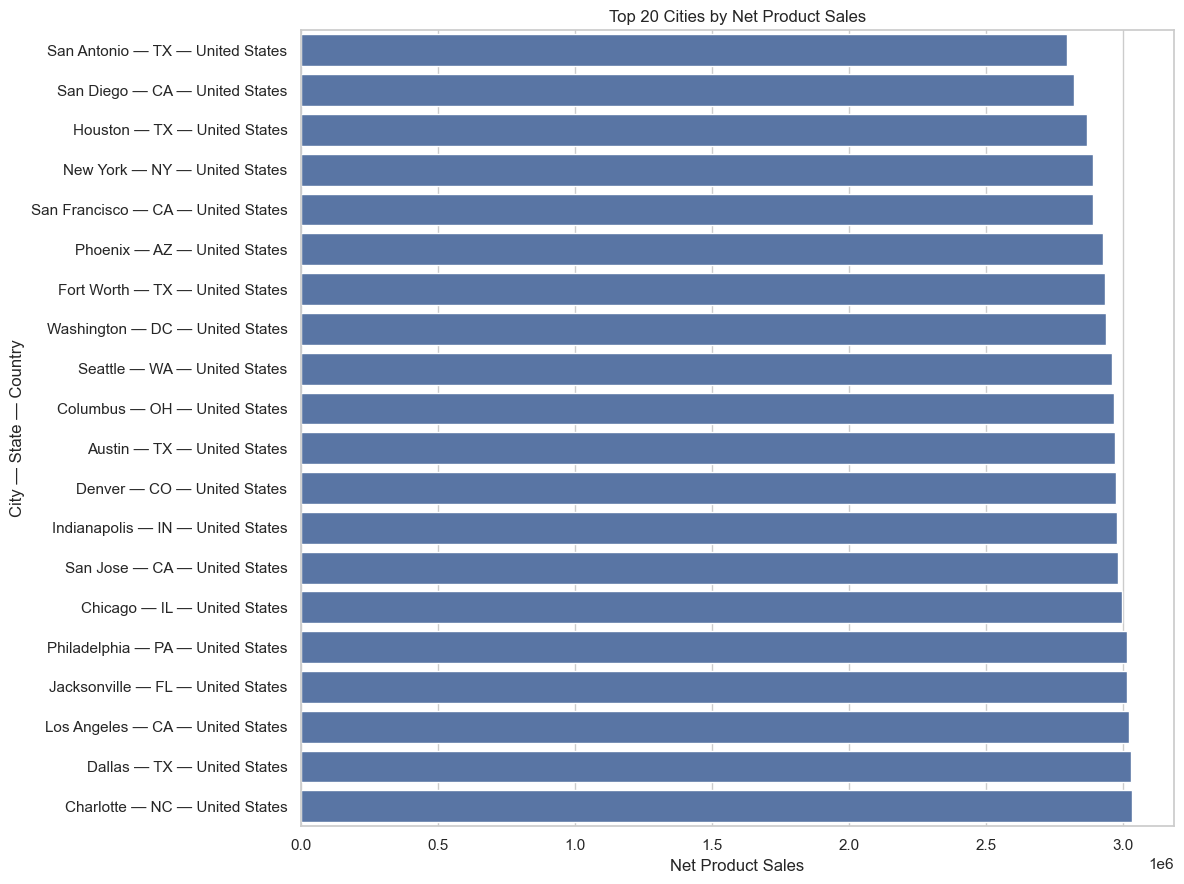

In [23]:
top_cities_plot = top_cities_sales.copy()

top_cities_plot["Location"] = (
    top_cities_plot["City"].astype(str)
    + " — "
    + top_cities_plot["State"].astype(str)
    + " — "
    + top_cities_plot["Country"].astype(str)
)

plt.figure(figsize=(12, 9))

sns.barplot(
    data=top_cities_plot.sort_values("NetProductSales"),
    x="NetProductSales",
    y="Location"
)

plt.title("Top 20 Cities by Net Product Sales")
plt.xlabel("Net Product Sales")
plt.ylabel("City — State — Country")

plt.tight_layout()
plt.show()


## 10. Top Cities by Customer Reach

This ranking focuses on the number of distinct customers rather than sales value.


In [24]:
top_cities_customers = (
    city_summary
    .sort_values("Customers", ascending=False)
    .head(20)
)

top_cities_customers[
    [
        "Country",
        "State",
        "City",
        "Customers",
        "Orders",
        "NetProductSales"
    ]
]


,Country,State,City,Customers,Orders,NetProductSales
84,United States,CA,San Jose,3492,3619,2.980571e+06
87,United States,FL,Jacksonville,3479,3594,3.015114e+06
90,United States,NC,Charlotte,3467,3606,3.033620e+06
81,United States,CA,Los Angeles,3445,3571,3.019624e+06
86,United States,DC,Washington,3433,3560,2.938880e+06
95,United States,TX,Dallas,3428,3549,3.028909e+06
93,United States,PA,Philadelphia,3409,3543,3.014939e+06
88,United States,IL,Chicago,3402,3507,2.996201e+06
92,United States,OH,Columbus,3392,3521,2.967673e+06
99,United States,WA,Seattle,3373,3504,2.958740e+06


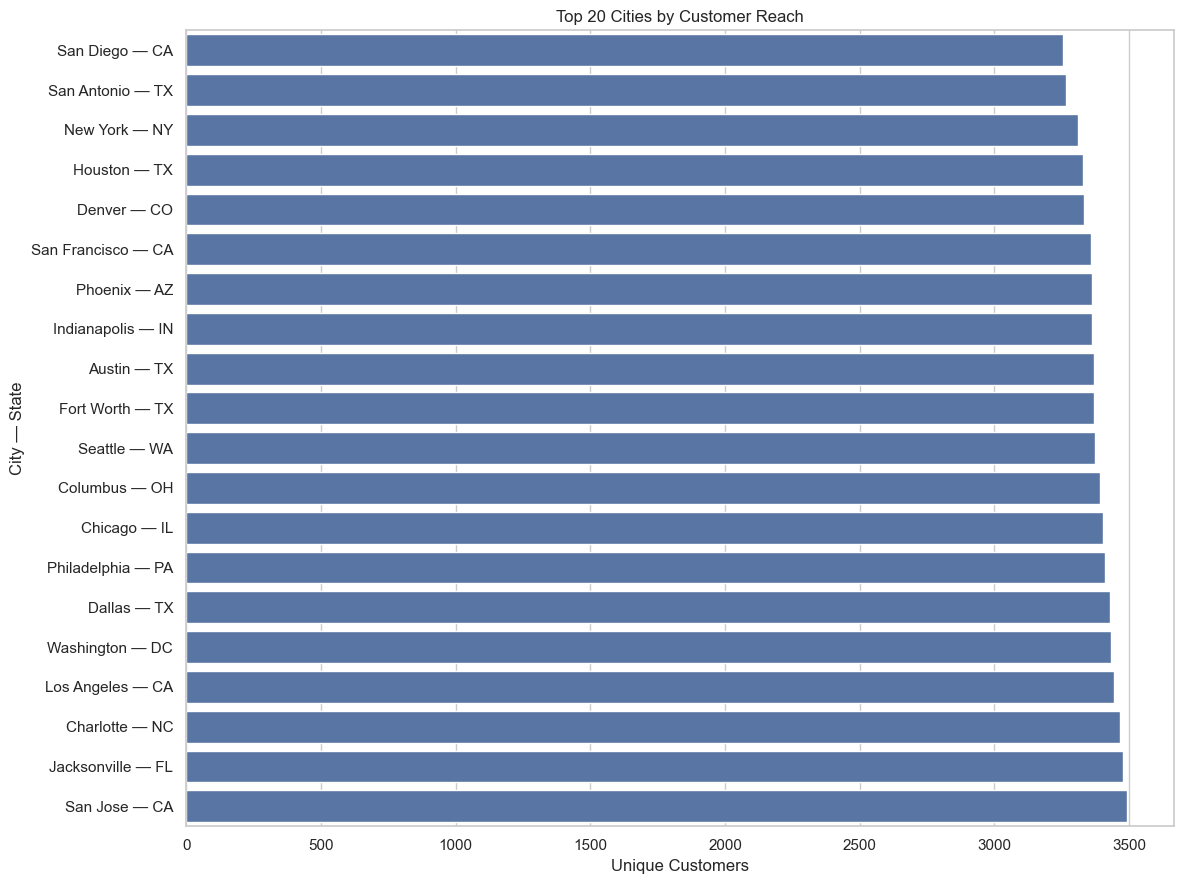

In [25]:
top_cities_customers_plot = top_cities_customers.copy()

top_cities_customers_plot["Location"] = (
    top_cities_customers_plot["City"].astype(str)
    + " — "
    + top_cities_customers_plot["State"].astype(str)
)

plt.figure(figsize=(12, 9))

sns.barplot(
    data=top_cities_customers_plot.sort_values("Customers"),
    x="Customers",
    y="Location"
)

plt.title("Top 20 Cities by Customer Reach")
plt.xlabel("Unique Customers")
plt.ylabel("City — State")

plt.tight_layout()
plt.show()


## 11. City-Level Average Order Value

High average order value can identify locations with a higher-value transaction mix.


In [26]:
top_cities_aov = (
    city_summary
    .sort_values("Average_Order_Value", ascending=False)
    .head(20)
)

top_cities_aov[
    [
        "Country",
        "State",
        "City",
        "Average_Order_Value",
        "Orders",
        "NetProductSales"
    ]
]


,Country,State,City,Average_Order_Value,Orders,NetProductSales
15,Australia,TX,Dallas,1020.345152,198,185958.3305
13,Australia,PA,Philadelphia,1007.057524,206,189206.4455
31,Canada,NY,New York,1005.557365,296,274248.2590
59,India,WA,Seattle,995.260109,734,670678.0680
4,Australia,CA,San Jose,989.564900,200,180505.3490
78,United Kingdom,TX,San Antonio,982.917722,259,235200.9390
10,Australia,NC,Charlotte,979.273158,209,187369.0300
24,Canada,CA,San Jose,978.632305,269,241998.7500
26,Canada,DC,Washington,977.887319,276,247375.7550
23,Canada,CA,San Francisco,976.721382,246,219116.9645


## 12. Geographic Sales Concentration

This section evaluates how dependent overall sales are on the largest geographic markets.

The concentration calculation is performed separately for countries, states, and cities.


In [27]:
country_ranked = (
    country_summary
    .sort_values("NetProductSales", ascending=False)
    .reset_index(drop=True)
)

country_ranked["Geography_Rank"] = country_ranked.index + 1

country_ranked["Cumulative_Sales_Share_%"] = (
    country_ranked["NetProductSales"].cumsum()
    / country_ranked["NetProductSales"].sum()
    * 100
)

country_ranked[
    [
        "Geography_Rank",
        "Country",
        "NetProductSales",
        "Sales_Share_%",
        "Cumulative_Sales_Share_%"
    ]
]


,Geography_Rank,Country,NetProductSales,Sales_Share_%,Cumulative_Sales_Share_%
0,1,United States,5.899402e+07,70.032468,70.032468
1,2,India,1.272826e+07,15.109856,85.142325
2,3,Canada,4.885633e+06,5.799791,90.942115
3,4,United Kingdom,4.155828e+06,4.933431,95.875546
4,5,Australia,3.474361e+06,4.124454,100.000000


In [28]:
state_ranked = (
    state_summary
    .sort_values("NetProductSales", ascending=False)
    .reset_index(drop=True)
)

state_ranked["Geography_Rank"] = state_ranked.index + 1

state_ranked["Cumulative_Sales_Share_%"] = (
    state_ranked["NetProductSales"].cumsum()
    / state_ranked["NetProductSales"].sum()
    * 100
)

state_ranked.head(20)


,Country,State,Orders,Customers,Cities,Sellers,Products,Categories,Units,GrossProductValue,DiscountAmount,NetProductSales,TotalOrderValue,Average_Order_Value,Average_Discount,Weighted_Discount_%,Sales_Share_%,Geography_Rank,Cumulative_Sales_Share_%
0,United States,TX,17334,14662,5,1999,50,6,52001,15759021.89,1.167770e+06,1.459125e+07,15897488.53,917.127526,0.073333,7.410167,17.321441,1,17.321441
1,United States,CA,14014,12277,4,1999,50,6,41949,12657897.56,9.455216e+05,1.171238e+07,12783662.94,912.206575,0.074336,7.469816,13.903895,2,31.225336
2,India,TX,3797,3648,5,1708,50,6,11322,3473829.43,2.591616e+05,3.214668e+06,3503209.66,922.625668,0.074783,7.460399,3.816169,3,35.041505
3,United States,NC,3606,3467,1,1652,50,6,10867,3280118.24,2.464979e+05,3.033620e+06,3311877.73,918.435311,0.074251,7.514910,3.601245,4,38.642750
4,United States,FL,3594,3479,1,1667,50,6,10870,3261080.99,2.459673e+05,3.015114e+06,3281693.36,913.103328,0.074610,7.542508,3.579276,5,42.222026
5,United States,PA,3543,3409,1,1684,50,6,10737,3260075.73,2.451369e+05,3.014939e+06,3287459.93,927.874663,0.074527,7.519363,3.579068,6,45.801094
6,United States,IL,3507,3402,1,1647,50,6,10521,3241592.32,2.453910e+05,2.996201e+06,3268618.39,932.026915,0.074950,7.570075,3.556825,7,49.357919
7,United States,IN,3469,3364,1,1659,50,6,10445,3221849.84,2.436980e+05,2.978152e+06,3246583.55,935.884563,0.075166,7.563914,3.535398,8,52.893317
8,United States,CO,3462,3334,1,1643,50,6,10511,3205263.52,2.331764e+05,2.972087e+06,3240143.04,935.916534,0.072039,7.274795,3.528199,9,56.421515
9,United States,OH,3521,3392,1,1661,50,6,10597,3187501.95,2.198293e+05,2.967673e+06,3237947.84,919.610293,0.070420,6.896602,3.522958,10,59.944473


In [29]:
city_ranked = (
    city_summary
    .sort_values("NetProductSales", ascending=False)
    .reset_index(drop=True)
)

city_ranked["Geography_Rank"] = city_ranked.index + 1

city_ranked["Cumulative_Sales_Share_%"] = (
    city_ranked["NetProductSales"].cumsum()
    / city_ranked["NetProductSales"].sum()
    * 100
)

city_ranked.head(20)


,Country,State,City,Orders,Customers,Sellers,Products,Categories,Units,GrossProductValue,DiscountAmount,NetProductSales,TotalOrderValue,Average_Order_Value,Average_Discount,Weighted_Discount_%,Sales_Share_%,Geography_Rank,Cumulative_Sales_Share_%
0,United States,NC,Charlotte,3606,3467,1652,50,6,10867,3280118.24,246497.9340,3.033620e+06,3311877.73,918.435311,0.074251,7.514910,3.601245,1,3.601245
1,United States,TX,Dallas,3549,3428,1676,50,6,10760,3277783.44,248874.1155,3.028909e+06,3302355.14,930.502998,0.074570,7.592757,3.595653,2,7.196898
2,United States,CA,Los Angeles,3571,3445,1686,50,6,10654,3264047.65,244423.9410,3.019624e+06,3293609.37,922.321302,0.075189,7.488369,3.584630,3,10.781528
3,United States,FL,Jacksonville,3594,3479,1667,50,6,10870,3261080.99,245967.3085,3.015114e+06,3281693.36,913.103328,0.074610,7.542508,3.579276,4,14.360803
4,United States,PA,Philadelphia,3543,3409,1684,50,6,10737,3260075.73,245136.9320,3.014939e+06,3287459.93,927.874663,0.074527,7.519363,3.579068,5,17.939872
5,United States,IL,Chicago,3507,3402,1647,50,6,10521,3241592.32,245390.9660,2.996201e+06,3268618.39,932.026915,0.074950,7.570075,3.556825,6,21.496696
6,United States,CA,San Jose,3619,3492,1665,50,6,10815,3220105.74,239534.6115,2.980571e+06,3256968.78,899.963741,0.075863,7.438719,3.538270,7,25.034966
7,United States,IN,Indianapolis,3469,3364,1659,50,6,10445,3221849.84,243697.9640,2.978152e+06,3246583.55,935.884563,0.075166,7.563914,3.535398,8,28.570364
8,United States,CO,Denver,3462,3334,1643,50,6,10511,3205263.52,233176.3550,2.972087e+06,3240143.04,935.916534,0.072039,7.274795,3.528199,9,32.098563
9,United States,TX,Austin,3481,3369,1657,50,6,10350,3202607.29,234129.4500,2.968478e+06,3235664.44,929.521528,0.072795,7.310589,3.523914,10,35.622477


In [30]:
top_5_country_share = (
    country_ranked.head(5)["NetProductSales"].sum()
    / country_ranked["NetProductSales"].sum()
    * 100
)

top_10_state_share = (
    state_ranked.head(10)["NetProductSales"].sum()
    / state_ranked["NetProductSales"].sum()
    * 100
)

top_20_city_share = (
    city_ranked.head(20)["NetProductSales"].sum()
    / city_ranked["NetProductSales"].sum()
    * 100
)

geographic_concentration = pd.DataFrame({
    "Geographic Measure": [
        "Top 5 Countries",
        "Top 10 Country-State Locations",
        "Top 20 Cities"
    ],
    "Sales Share (%)": [
        top_5_country_share,
        top_10_state_share,
        top_20_city_share
    ]
})

geographic_concentration


,Geographic Measure,Sales Share (%)
0,Top 5 Countries,100.000000
1,Top 10 Country-State Locations,59.944473
2,Top 20 Cities,70.032468


## 13. Country × Category Performance

This section identifies which product categories perform strongly within each country.

It can help distinguish country-level demand patterns from overall marketplace rankings.


In [31]:
country_category_sales = (
    df.groupby(["Country", "Category"])
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
)

country_category_sales["Country_Category_Sales_Share_%"] = (
    country_category_sales["NetProductSales"]
    / country_category_sales.groupby("Country")["NetProductSales"].transform("sum")
    * 100
)

country_category_sales = country_category_sales.sort_values(
    ["Country", "NetProductSales"],
    ascending=[True, False]
)

country_category_sales.head(30)


,Country,Category,Orders,Customers,Units,NetProductSales,Country_Category_Sales_Share_%
0,Australia,Books,718,712,2150,6.117273e+05,17.606901
1,Australia,Clothing,706,701,2091,6.014287e+05,17.310483
2,Australia,Electronics,714,707,2173,6.012982e+05,17.306726
4,Australia,Sports & Outdoors,697,689,2135,5.868765e+05,16.891636
5,Australia,Toys & Games,676,671,2051,5.661277e+05,16.294440
3,Australia,Home & Kitchen,619,617,1837,5.069028e+05,14.589813
8,Canada,Electronics,966,957,2957,8.450775e+05,17.297195
9,Canada,Home & Kitchen,1002,992,3010,8.367345e+05,17.126430
11,Canada,Toys & Games,978,971,2925,8.254315e+05,16.895077
10,Canada,Sports & Outdoors,990,983,2919,8.155235e+05,16.692280


In [32]:
top_category_by_country = (
    country_category_sales
    .sort_values(
        ["Country", "NetProductSales"],
        ascending=[True, False]
    )
    .groupby("Country")
    .head(1)
    .reset_index(drop=True)
)

top_category_by_country


,Country,Category,Orders,Customers,Units,NetProductSales,Country_Category_Sales_Share_%
0,Australia,Books,718,712,2150,6.117273e+05,17.606901
1,Canada,Electronics,966,957,2957,8.450775e+05,17.297195
2,India,Sports & Outdoors,2578,2508,7723,2.153599e+06,16.919832
3,United Kingdom,Clothing,829,826,2518,7.341709e+05,17.666055
4,United States,Electronics,11735,10443,35413,9.982710e+06,16.921563


## 14. Country × Seller Performance

The leading seller in each country is identified using net product sales.

This helps connect geographic markets with seller performance without replacing the detailed Seller Analysis notebook.


In [33]:
country_seller_sales = (
    df.groupby(["Country", "SellerID"])
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
)

top_seller_by_country = (
    country_seller_sales
    .sort_values(
        ["Country", "NetProductSales"],
        ascending=[True, False]
    )
    .groupby("Country")
    .head(1)
    .reset_index(drop=True)
)

top_seller_by_country


,Country,SellerID,Orders,Customers,Units,NetProductSales
0,Australia,SELL01090,6,6,23,8514.2905
1,Canada,SELL00464,10,10,31,9971.2745
2,India,SELL00777,14,14,42,17383.2460
3,United Kingdom,SELL00176,5,5,21,9807.4620
4,United States,SELL00440,49,49,162,52781.6300


## 15. Geographic Order Status Analysis

Order status is compared across countries to identify differences in the recorded transaction outcome mix.

The dataset's status values are used directly.


In [34]:
country_order_status = pd.crosstab(
    df["Country"],
    df["OrderStatus"]
)

country_order_status


OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
Country,,,,,
Australia,122,3093,183,97,635
Canada,186,4306,238,179,909
India,443,11310,614,457,2227
United Kingdom,154,3654,191,157,787
United States,2123,52265,2877,2159,10634


In [35]:
country_order_status_percentage = (
    pd.crosstab(
        df["Country"],
        df["OrderStatus"],
        normalize="index"
    )
    * 100
)

country_order_status_percentage


OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
Country,,,,,
Australia,2.953995,74.891041,4.430993,2.348668,15.375303
Canada,3.196975,74.011688,4.090753,3.076659,15.623926
India,2.943326,75.144509,4.079463,3.036343,14.796359
United Kingdom,3.115517,73.922719,3.864050,3.176209,15.921505
United States,3.030346,74.602472,4.106597,3.081732,15.178852


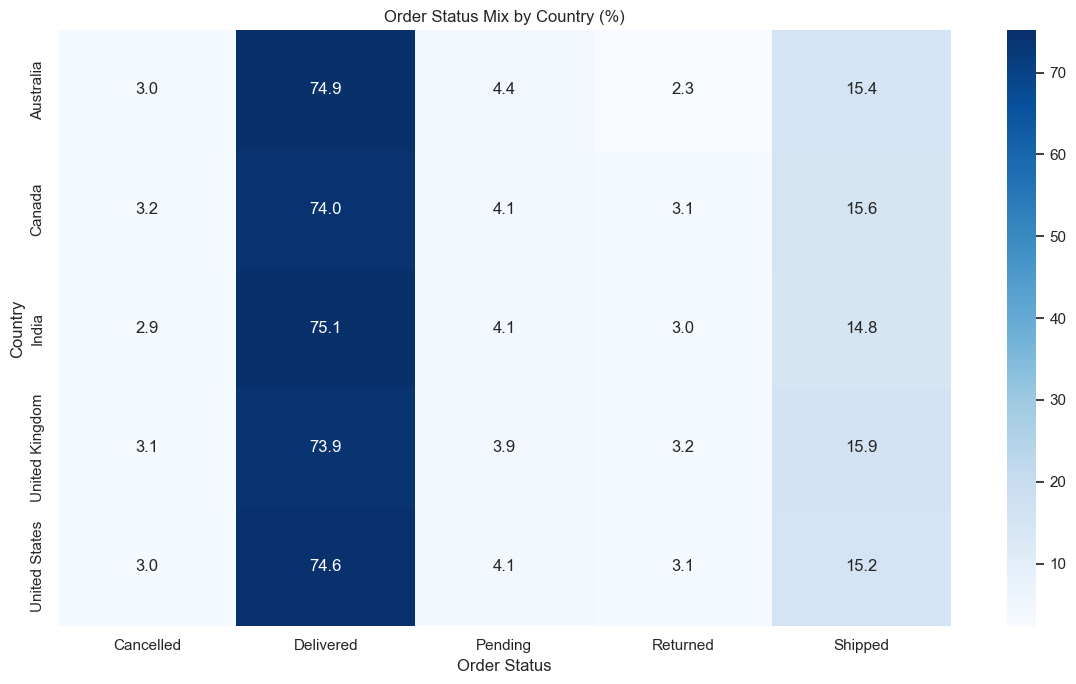

In [36]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    country_order_status_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Order Status Mix by Country (%)")
plt.xlabel("Order Status")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


## 16. Geographic Sales vs Customer Reach

The following scatter plot compares market sales with unique customer counts.

Bubble size represents order volume.


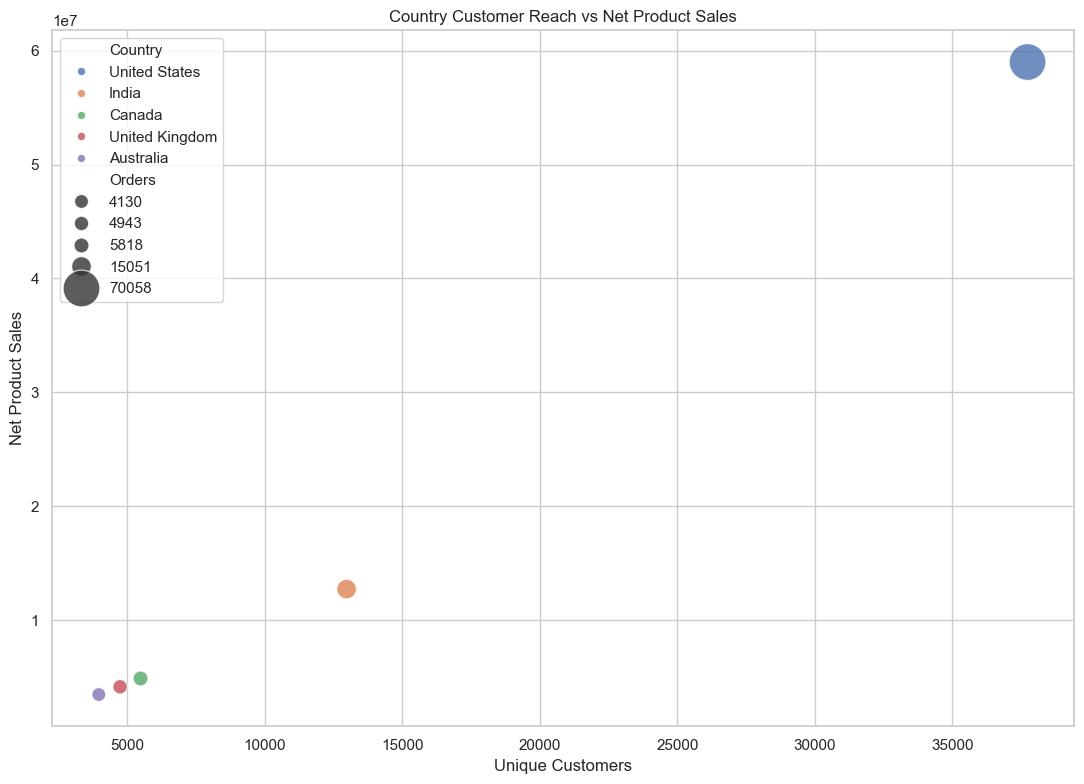

In [37]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=country_summary,
    x="Customers",
    y="NetProductSales",
    size="Orders",
    hue="Country",
    sizes=(100, 700),
    alpha=0.8
)

plt.title("Country Customer Reach vs Net Product Sales")
plt.xlabel("Unique Customers")
plt.ylabel("Net Product Sales")

plt.tight_layout()
plt.show()


## 17. Geographic Sales vs Units

This comparison helps distinguish markets driven primarily by transaction volume from markets driven by higher-value products or orders.


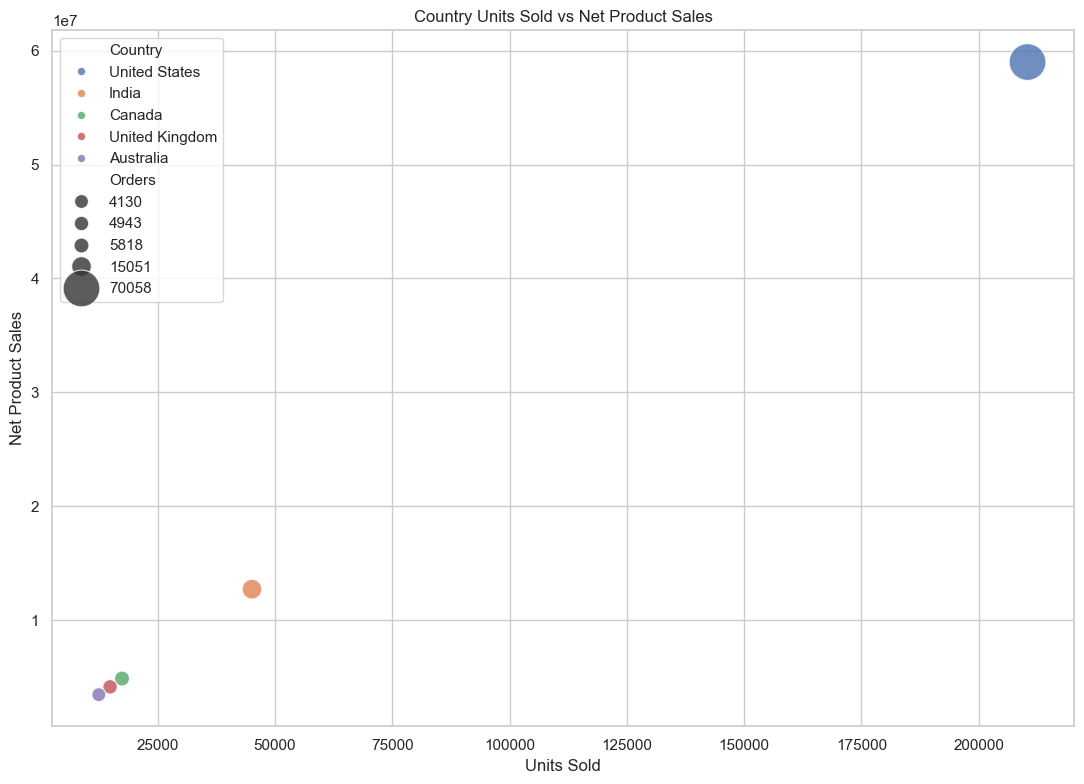

In [38]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=country_summary,
    x="Units",
    y="NetProductSales",
    size="Orders",
    hue="Country",
    sizes=(100, 700),
    alpha=0.8
)

plt.title("Country Units Sold vs Net Product Sales")
plt.xlabel("Units Sold")
plt.ylabel("Net Product Sales")

plt.tight_layout()
plt.show()


## 18. Geographic Performance Score

A simple comparative score is created at the country level using percentile ranks across:

- Net Product Sales
- Orders
- Customers
- Units
- Number of Cities

Each dimension receives equal weight.

This is an analytical ranking, not an official market score.


In [39]:
country_score = country_summary[
    [
        "Country",
        "NetProductSales",
        "Orders",
        "Customers",
        "Units",
        "Cities"
    ]
].copy()

score_metrics = [
    "NetProductSales",
    "Orders",
    "Customers",
    "Units",
    "Cities"
]

for metric in score_metrics:
    country_score[f"{metric}_Percentile"] = (
        country_score[metric].rank(pct=True) * 100
    )

country_percentile_columns = [
    f"{metric}_Percentile"
    for metric in score_metrics
]

country_score["Geographic_Performance_Score"] = (
    country_score[country_percentile_columns].mean(axis=1)
)

country_score = country_score.sort_values(
    "Geographic_Performance_Score",
    ascending=False
)

country_score


,Country,NetProductSales,Orders,Customers,Units,Cities,NetProductSales_Percentile,Orders_Percentile,Customers_Percentile,Units_Percentile,Cities_Percentile,Geographic_Performance_Score
4,United States,5.899402e+07,70058,37731,210409,20,100.0,100.0,100.0,100.0,60.0,92.0
2,India,1.272826e+07,15051,12976,45082,20,80.0,80.0,80.0,80.0,60.0,76.0
1,Canada,4.885633e+06,5818,5486,17381,20,60.0,60.0,60.0,60.0,60.0,60.0
3,United Kingdom,4.155828e+06,4943,4742,14831,20,40.0,40.0,40.0,40.0,60.0,44.0
0,Australia,3.474361e+06,4130,3969,12437,20,20.0,20.0,20.0,20.0,60.0,28.0


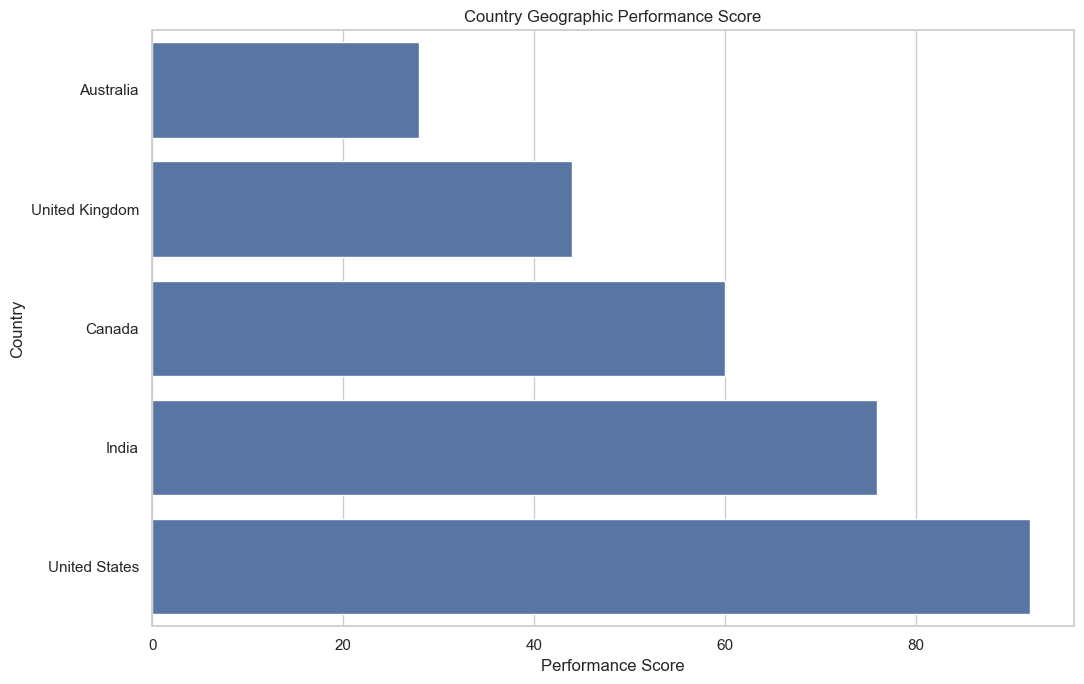

In [40]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=country_score.sort_values("Geographic_Performance_Score"),
    x="Geographic_Performance_Score",
    y="Country"
)

plt.title("Country Geographic Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


## 19. Country Performance Heatmap

The heatmap presents the normalized country-level performance profile.


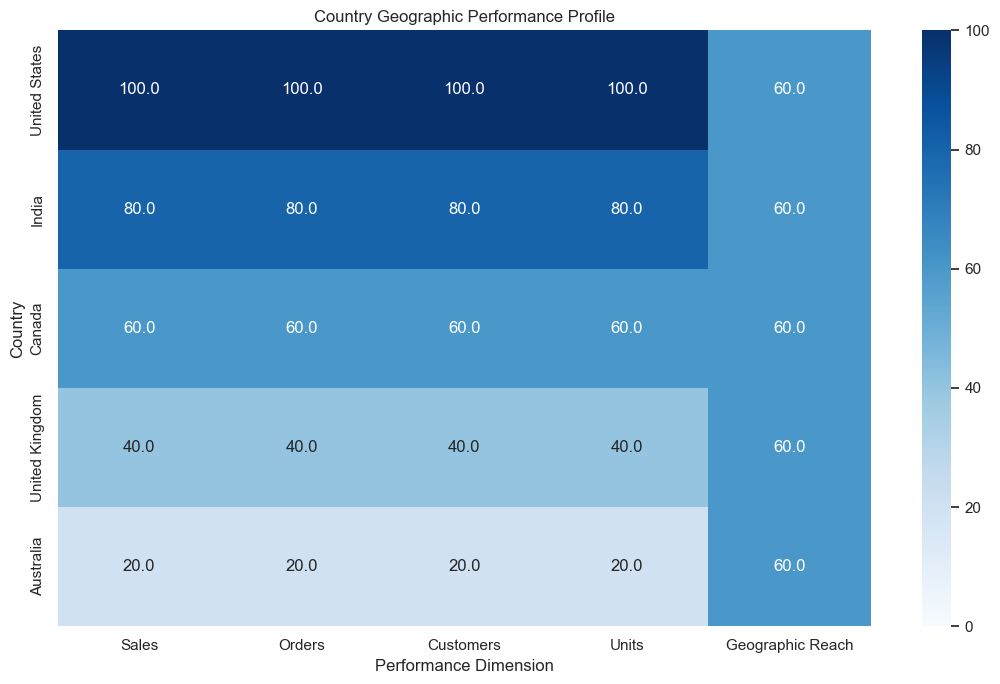

In [41]:
country_heatmap = (
    country_score
    .set_index("Country")[country_percentile_columns]
    .rename(columns={
        "NetProductSales_Percentile": "Sales",
        "Orders_Percentile": "Orders",
        "Customers_Percentile": "Customers",
        "Units_Percentile": "Units",
        "Cities_Percentile": "Geographic Reach"
    })
)

plt.figure(figsize=(11, 7))

sns.heatmap(
    country_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title("Country Geographic Performance Profile")
plt.xlabel("Performance Dimension")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


## 20. Direct Business Answers

The following cells provide direct answers to the main geographic questions.


In [42]:
best_country_sales = country_summary.loc[
    country_summary["NetProductSales"].idxmax()
]

best_country_orders = country_summary.loc[
    country_summary["Orders"].idxmax()
]

best_country_customers = country_summary.loc[
    country_summary["Customers"].idxmax()
]

best_country_units = country_summary.loc[
    country_summary["Units"].idxmax()
]

best_country_aov = country_summary.loc[
    country_summary["Average_Order_Value"].idxmax()
]

best_country_discount = country_summary.loc[
    country_summary["Weighted_Discount_%"].idxmax()
]

best_city_sales = city_summary.loc[
    city_summary["NetProductSales"].idxmax()
]

print(
    f"Highest-sales country: {best_country_sales['Country']} "
    f"(${best_country_sales['NetProductSales']:,.2f})"
)

print(
    f"Highest-order country: {best_country_orders['Country']} "
    f"({int(best_country_orders['Orders']):,} orders)"
)

print(
    f"Highest-customer country: {best_country_customers['Country']} "
    f"({int(best_country_customers['Customers']):,} customers)"
)

print(
    f"Highest-unit country: {best_country_units['Country']} "
    f"({int(best_country_units['Units']):,} units)"
)

print(
    f"Highest-AOV country: {best_country_aov['Country']} "
    f"(${best_country_aov['Average_Order_Value']:,.2f})"
)

print(
    f"Highest-weighted-discount country: {best_country_discount['Country']} "
    f"({best_country_discount['Weighted_Discount_%']:.2f}%)"
)

print(
    f"Highest-sales city: {best_city_sales['City']} "
    f"({best_city_sales['State']}, {best_city_sales['Country']}) "
    f"(${best_city_sales['NetProductSales']:,.2f})"
)


Highest-sales country: United States ($58,994,016.27)
Highest-order country: United States (70,058 orders)
Highest-customer country: United States (37,731 customers)
Highest-unit country: United States (210,409 units)
Highest-AOV country: India ($921.92)
Highest-weighted-discount country: Australia (7.57%)
Highest-sales city: Charlotte (NC, United States) ($3,033,620.31)


## 21. Final Geographic Insights

### Country Performance
Country-level rankings identify the strongest observed geographic markets by sales, orders, customers, and units.

### State Performance
State-level analysis provides a more detailed view of where sales are concentrated within the dataset.

### City Performance
City-level rankings identify individual markets that contribute significant sales and customer activity.

### Market Concentration
The concentration analysis shows whether a large proportion of sales comes from a relatively small number of geographic markets.

### Customer Reach
A market with many customers is not necessarily the highest-sales market. Comparing customer reach with sales helps identify differences in transaction value.

### Category Demand
Country-category analysis highlights which categories contribute most within each country.

### Seller Presence
Country-seller analysis identifies the leading seller in each geographic market.

### Operational Mix
Country-level order-status analysis can reveal differences in the recorded status distribution across markets.

### Data Limitation
The dataset does not contain latitude/longitude, delivery distance, population, market size, regional operating costs, or detailed logistics data. Therefore, this notebook measures transaction-based geographic performance rather than geographic potential or profitability.


## 22. Export Geographic Analysis Outputs

The key geographic tables are exported so they can be reused in the SQL and Power BI stages of the project.


In [43]:
output_dir = Path("../data/geographic_analysis_outputs")

output_dir.mkdir(parents=True, exist_ok=True)

geographic_overview.to_csv(
    output_dir / "geographic_overview.csv",
    index=False
)

country_summary.to_csv(
    output_dir / "country_summary.csv",
    index=False
)

state_summary.to_csv(
    output_dir / "state_summary.csv",
    index=False
)

city_summary.to_csv(
    output_dir / "city_summary.csv",
    index=False
)

country_ranked.to_csv(
    output_dir / "country_sales_concentration.csv",
    index=False
)

state_ranked.to_csv(
    output_dir / "state_sales_concentration.csv",
    index=False
)

city_ranked.to_csv(
    output_dir / "city_sales_concentration.csv",
    index=False
)

geographic_concentration.to_csv(
    output_dir / "geographic_concentration_summary.csv",
    index=False
)

country_category_sales.to_csv(
    output_dir / "country_category_sales.csv",
    index=False
)

top_category_by_country.to_csv(
    output_dir / "top_category_by_country.csv",
    index=False
)

country_seller_sales.to_csv(
    output_dir / "country_seller_sales.csv",
    index=False
)

top_seller_by_country.to_csv(
    output_dir / "top_seller_by_country.csv",
    index=False
)

country_order_status_percentage.to_csv(
    output_dir / "country_order_status_percentage.csv"
)

country_score.to_csv(
    output_dir / "country_geographic_performance_score.csv",
    index=False
)

print("Geographic analysis outputs exported successfully.")
print("Output directory:", output_dir)


Geographic analysis outputs exported successfully.
Output directory: ..\data\geographic_analysis_outputs


# 23. Conclusion

This notebook provided a structured geographic analysis of the e-commerce marketplace.

The analysis examined:

- Country-level sales and customer performance
- State-level sales concentration
- City-level sales performance
- Customer reach
- Units sold
- Average order value
- Discount behavior by geography
- Geographic sales concentration
- Country-category performance
- Country-seller performance
- Order-status mix by country
- Geographic performance scoring

The results provide a geographic perspective that complements the previous Seller Analysis notebook.

